In [44]:
import torch
import torch.nn as nn
import pandas as pd
from utils.model_utils import validate, train, evaluate, get_tensor_dataset, get_data_loader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [45]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
val_df = pd.read_csv('data/val.csv')

In [48]:
label = 'label'
train_dataset = get_tensor_dataset(train_df, label)
test_dataset = get_tensor_dataset(test_df, label)
val_dataset = get_tensor_dataset(val_df, label)

print(train_dataset)
print(test_dataset)
print(val_dataset)

In [49]:
BATCH_SIZE = 32
train_loader = get_data_loader(train_dataset, BATCH_SIZE)
test_loader = get_data_loader(test_dataset, BATCH_SIZE)
val_loader = get_data_loader(val_dataset, BATCH_SIZE)

In [50]:
model = nn.Sequential(
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(64, 1)
)
model.to(device)
print(model)

Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=64, out_features=1, bias=True)
)


In [51]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
THRESHOLD = 0.2599

In [52]:
best_loss = float('inf')
patience = 5
counter = 0

for epoch in range(50):
    print("Epoch:", epoch)
    train(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        optimizer=optimizer,
        train_loader=train_loader,
        device=device
    )
    val_loss = validate(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        val_loader=val_loader,
        device=device
    )
    print("-" * 40)

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "../model_repository/pneumonia_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

Epoch: 0
Train - Loss: 0.2067 Accuracy: 0.8902
Valid - Loss: 0.1597 Accuracy: 0.8990
----------------------------------------
Epoch: 1
Train - Loss: 0.1346 Accuracy: 0.9400
Valid - Loss: 0.1718 Accuracy: 0.9425
----------------------------------------
Epoch: 2
Train - Loss: 0.1134 Accuracy: 0.9460
Valid - Loss: 0.1131 Accuracy: 0.9604
----------------------------------------
Epoch: 3
Train - Loss: 0.0857 Accuracy: 0.9589
Valid - Loss: 0.1100 Accuracy: 0.9412
----------------------------------------
Epoch: 4
Train - Loss: 0.0899 Accuracy: 0.9603
Valid - Loss: 0.0824 Accuracy: 0.9540
----------------------------------------
Epoch: 5
Train - Loss: 0.0787 Accuracy: 0.9625
Valid - Loss: 0.1076 Accuracy: 0.9463
----------------------------------------
Epoch: 6
Train - Loss: 0.0788 Accuracy: 0.9647
Valid - Loss: 0.1039 Accuracy: 0.9642
----------------------------------------
Epoch: 7
Train - Loss: 0.0718 Accuracy: 0.9682
Valid - Loss: 0.1494 Accuracy: 0.9194
---------------------------------

===== EVALUATION METRICS =====
Accuracy  : 0.9706
Precision : 0.9745
Recall    : 0.9863
F1 Score  : 0.9804

Confusion Matrix:
 [[186  15]
 [  8 574]]

Detailed Classification Report:

              precision    recall  f1-score   support

         0.0       0.96      0.93      0.94       201
         1.0       0.97      0.99      0.98       582

    accuracy                           0.97       783
   macro avg       0.97      0.96      0.96       783
weighted avg       0.97      0.97      0.97       783



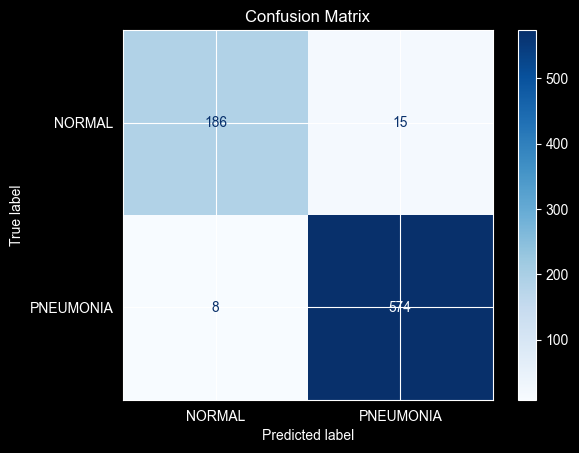

In [53]:
evaluate(model=model,
         threshold=THRESHOLD,
         data_loader=test_loader,
         device=device)